# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)

***
## 2. Load data

In [ ]:
df = pd.read_csv('../resources/clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [ ]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

***

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [ ]:
price_df = pd.read_csv('../resources/price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [ ]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()
# Here it is not necessary to get the averages since there is only one price per date and company
monthly_price_by_id.sample(2)

,id,price_date,price_off_peak_var,price_off_peak_fix
138859,b8bd768b39a85f95b89332ea63a26b6a,2015-10-01,0.146788,44.44471
35275,2d2cb8913436e61567f02f35609ffeef,2015-12-01,0.147678,44.44471


In [ ]:

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()
display(jan_prices.sample(2))
display(dec_prices.sample(2))


,id,price_date,price_off_peak_var,price_off_peak_fix
3086,2fc445f99c487f06a7c936229407fa59,2015-01-01,0.19190,45.760931
11348,b51fcced5ef7605a11cc736d916acc90,2015-01-01,0.15524,44.444710


,id,price_date,price_off_peak_var,price_off_peak_fix
7741,7b027a3b4fe4d8e09c51a6f718287582,2015-12-01,0.166056,44.44471
14089,dfa0c97e0da76db2d14454bbbd42c60f,2015-12-01,0.146208,44.44471


In [ ]:
# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
display(diff.head(2))

,id,price_date,dec_1,dec_2,price_off_peak_var,price_off_peak_fix
0,0002203ffbb812588b632b9e628cc38d,2015-12-01,0.119906,40.728885,0.126098,40.565969
1,0004351ebdd665e6ee664792efc4fd13,2015-12-01,0.143943,44.444710,0.148047,44.266931


In [ ]:
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.sample(2)

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
8893,8da555fd7fb1ad45a5485ca1d9f1e84b,-0.006192,0.162916
7489,7723047a47d503b16382c3f33d6d3fb8,-0.005508,0.177779


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

In [ ]:
df.shape

(14606, 44)

# Notes on the current data

## A. On the clients in the clean dataset, client and price datasets 

The clean database have the same number of unique clients as client_data.csv and less than the number of clients in the database price_data.csv. **All the clients in df** are in price_df.   

In [ ]:
display(df["id"].unique().shape)
display(price_df["id"].unique().shape)
display(len( 
    np.intersect1d(
        df["id"].unique(), price_df["id"].unique()
    )))

(14606,)

(16096,)

14606

## B. Channel sales
The channels_sales showed that some channels did not have churning clients. It could be due to a low number of samples for those channels.

In [ ]:
df.groupby(["channel_sales", "churn"])['id'].count()

channel_sales                     churn
MISSING                           0        3442
                                  1         283
epumfxlbckeskwekxbiuasklxalciiuu  0           3
ewpakwlliwisiwduibdlfmalxowmwpci  0         818
                                  1          75
fixdbufsefwooaasfcxdxadsiekoceaa  0           2
foosdfpfkusacimwkcsosbicdxkicaua  0        5934
                                  1         820
lmkebamcaaclubfxadlmueccxoimlema  0        1740
                                  1         103
sddiedcslfslkckwlfkdpoeeailfpeds  0          11
usilxuppasemubllopkaafesmlibmsdf  0        1237
                                  1         138
Name: id, dtype: int64

## C. Fields of interest from Task 2

1. There are 5 sales channels "**channel_sales**" with churn and 3 without any churning clients.  
2. Consumption fields show a highly skewed data.    
3. Forecast shows highly positively skewed data.  
4. Has gas or not shows a very similar percentage of churning (maybe not an interesting column)  
5. Margins show highly positively skewed data.  
6. Subscribed power shows also long right tails of skewed data.  
7. Number of products "**nb_prod_act**" (Similar churning perc for 1 to 5 products, 6 to 32 products shows no churning)  
8. Number of years of antiquity. If it is 1 year, no churning.  
9. There are some campains "**origin_up**" that has no churning.  
10. The **variable prices peak and mid-peak** are higher for those clients that churned than for those that didn't.    

# Tasks for Feature Engineering:

1. Remove "non-relevant" columns from datasets.
2. Expand datasets with new columns or create new features (dates->year, month, day) (one-hot encoding...)
3. Combine columns to get a field that can achieve better predictions in a model  
4. Merge datasets that expands the information. Both dataframes should share a common column.  


# Simplify data

After the Exploratory Data Analysis (Task 2), I will try to keep the analysis simple with a low number of parameters that seem to give a clear distinction of clients that churned and those that did not.  


In [ ]:
# Save the id and unique sales channel identifier in the output dataframe
df_out = pd.DataFrame()
df_out["id"] = df["id"]
df_out["churn"] = df["churn"]


### Channel sales

In [ ]:
# Unique values of the channel sales
ch_ids = df["channel_sales"].unique()
# Make a dict assigning a unique integer identifier to each channel_sales 
channels_map = {k:v for (k, v) in zip(ch_ids, range(len(ch_ids))) }
channels_map

{'foosdfpfkusacimwkcsosbicdxkicaua': 0,
 'MISSING': 1,
 'lmkebamcaaclubfxadlmueccxoimlema': 2,
 'usilxuppasemubllopkaafesmlibmsdf': 3,
 'ewpakwlliwisiwduibdlfmalxowmwpci': 4,
 'epumfxlbckeskwekxbiuasklxalciiuu': 5,
 'sddiedcslfslkckwlfkdpoeeailfpeds': 6,
 'fixdbufsefwooaasfcxdxadsiekoceaa': 7}

Add the channel sales unique integer identifier to the output df

In [ ]:
df_out["ch_sales_id"] = df["channel_sales"].map(channels_map)

In [ ]:
y1 = df_out.groupby("ch_sales_id").agg({'id':'count', 'churn':'sum'})
y1["churn_perc"] = (y1["churn"]/y1["id"]*100).round(decimals=1)
display(y1)

,id,churn,churn_perc
ch_sales_id,,,
0,6754,820,12.1
1,3725,283,7.6
2,1843,103,5.6
3,1375,138,10.0
4,893,75,8.4
5,3,0,0.0
6,11,0,0.0
7,2,0,0.0


## Consumption

The consumption data shows a large number of clients that consumed 0:

In [ ]:
# Consumption 0 for all clients
cons12m_0 = (df["cons_12m"] == 0.0).sum()

# Consumption 0 for those that has gas
cond_cons_gas = (df["has_gas"]=='t') & (df["cons_gas_12m"]==0.0)
cons_gas_0 = cond_cons_gas.sum()

# Consumption of last month = 0
cons_lastm_0 = (df["cons_last_month"] == 0.0).sum()

# Current paid consumption
imp_cons_0 = (df["imp_cons"] == 0.0).sum()

results = {
    "Consumption 0 for all clients": cons12m_0,
    "Consumption 0 for clients with gas": cons_gas_0,
    "Consumption last month = 0": cons_lastm_0,
    "Current paid consumption = 0": imp_cons_0
}

display(
    pd.DataFrame.from_dict(results, orient="index", columns=["Count"])
    )

,Count
Consumption 0 for all clients,117
Consumption 0 for clients with gas,92
Consumption last month = 0,4983
Current paid consumption = 0,6169


It may be interesting to add a column to filter if the consumption values are 0 so it can be used in a decision tree

In [ ]:
df_out["cons12m_is_zero"] = (df["cons_12m"] == 0.0).astype(int)
df_out["cons_gas_12m_is_zero"] = (df["cons_gas_12m"] == 0.0).astype(int)
df_out["cons_last_month_is_zero"] = (df["cons_last_month"] == 0.0).astype(int)
df_out["imp_cons_is_zero"] = (df["imp_cons"] == 0.0).astype(int)
df_out.sample(3)


,id,churn,ch_sales_id,cons12m_is_zero,cons_gas_12m_is_zero,cons_last_month_is_zero,imp_cons_is_zero
12695,38849c0404d66292fe177c09b179a225,0,4,0,0,0,0
11740,74ee25a056aa668b3e8eee92673c7ba8,0,0,0,1,0,0
9153,24c8cbb6aa7eac94400b3917e765c2b6,0,3,0,1,0,0


And to deal with 0 values and long tail distributions we can apply techniques to reduce the high skewness of the data, such as applying sqrt, logarithms...

In [ ]:
def ln_xplus1(df, cols, inplace=True, suffix="ln1p"):
    """
    Apply log1p transformation (ln(1+x)) to one or more DataFrame columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    cols : str or list of str
        Column name(s) to transform. 
        - If str → single column
        - If list of str → multiple columns
    inplace : bool, default=True
        If True, modify DataFrame in place.
        If False, return a new DataFrame.
    suffix : str, default="ln1p"
        Prefix for new column names.

    Returns
    -------
    pd.DataFrame
        DataFrame with new transformed columns.
    """
    if isinstance(cols, str):
        cols = [cols]
    elif not isinstance(cols, (list, tuple)):
        raise TypeError("`cols` must be a string or list/tuple of strings.")

    missing = set(cols) - set(df.columns)
    if missing:
        raise ValueError(f"Columns not found in DataFrame: {missing}")

    target = df if inplace else df.copy()

    for col in cols:
        target[f"{suffix}_{col}"] = np.log1p(target[col])

    return target

# a = ln_xplus1(df, cols="cons_12m", inplace=False)
# a.head(2)

In [ ]:
cons_list = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons']
consumption = ln_xplus1(df[cons_list], cols=cons_list, inplace=False)
consumption[['id', 'has_gas', 'churn']] = df[['id', 'has_gas', 'churn']]

In [ ]:
consumption.columns

Index(['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons',
       'ln1p_cons_12m', 'ln1p_cons_gas_12m', 'ln1p_cons_last_month',
       'ln1p_imp_cons', 'id', 'has_gas', 'churn'],
      dtype='object')

In [ ]:
def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distribution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

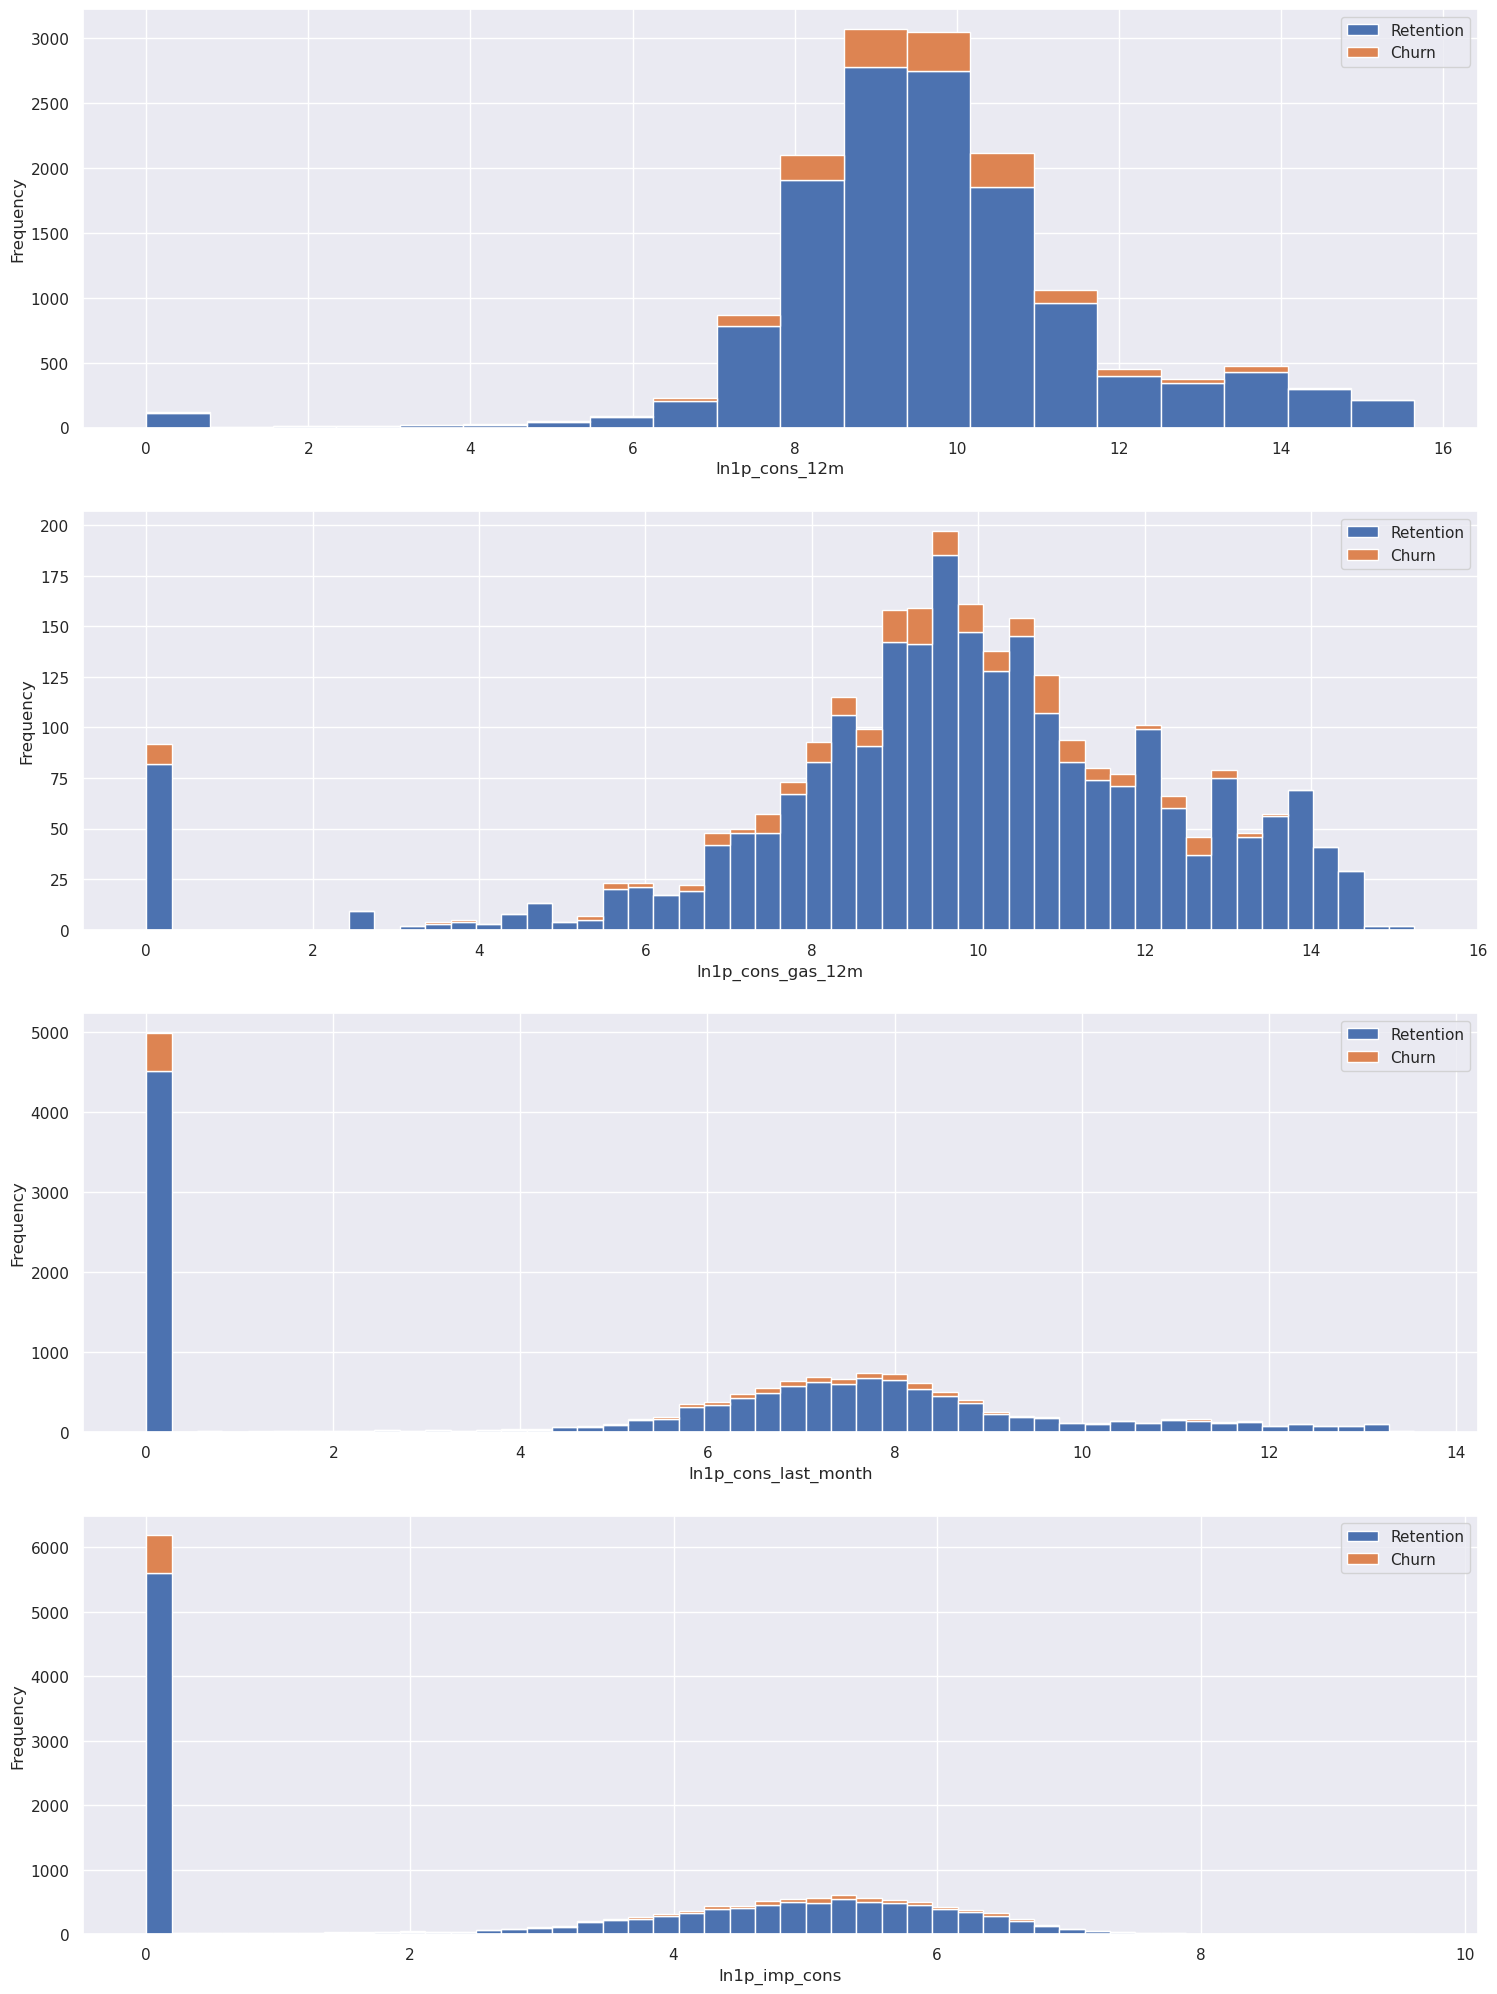

In [ ]:
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

# plot_distribution(consumption, 'cons_12m', axs[0], bins_=50)
plot_distribution(consumption, 'ln1p_cons_12m', axs[0], bins_=20)
plot_distribution(consumption[consumption['has_gas'] == 't'], 'ln1p_cons_gas_12m', axs[1])
plot_distribution(consumption, 'ln1p_cons_last_month', axs[2])
plot_distribution(consumption, 'ln1p_imp_cons', axs[3])

Add this data to df_out

In [ ]:
# New fields
transformed_consumption = list(map(lambda x: f"ln1p_{x}", cons_list))
print(transformed_consumption)

['ln1p_cons_12m', 'ln1p_cons_gas_12m', 'ln1p_cons_last_month', 'ln1p_imp_cons']


In [ ]:
# New transformed columns and has_gas column if they are not in df_out
missing_cols = (set(transformed_consumption) | {"has_gas"}) - set(df_out.columns)
# Convert to list so I can use it in the dataframe
missing_cols = list(missing_cols)
# Add the missing columns to the output dataframe
df_out[missing_cols] = consumption[missing_cols]

print(df_out.columns)

Index(['id', 'churn', 'ch_sales_id', 'cons12m_is_zero', 'cons_gas_12m_is_zero',
       'cons_last_month_is_zero', 'imp_cons_is_zero', 'ln1p_cons_last_month',
       'ln1p_cons_12m', 'ln1p_imp_cons', 'has_gas', 'ln1p_cons_gas_12m'],
      dtype='object')


## Forecast

The forecast fields also shows positive long tail distributions and outliers. We can apply the logaritmic transformations: 

In [ ]:
forecast_list = ["forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak"
    ]

# Transform the forecast fields
transf_forecast = ln_xplus1(df[forecast_list], cols=forecast_list, inplace=False)
list_transf_forecast = list(map(lambda x: f"ln1p_{x}", forecast_list))
transf_forecast["churn"] = df["churn"]

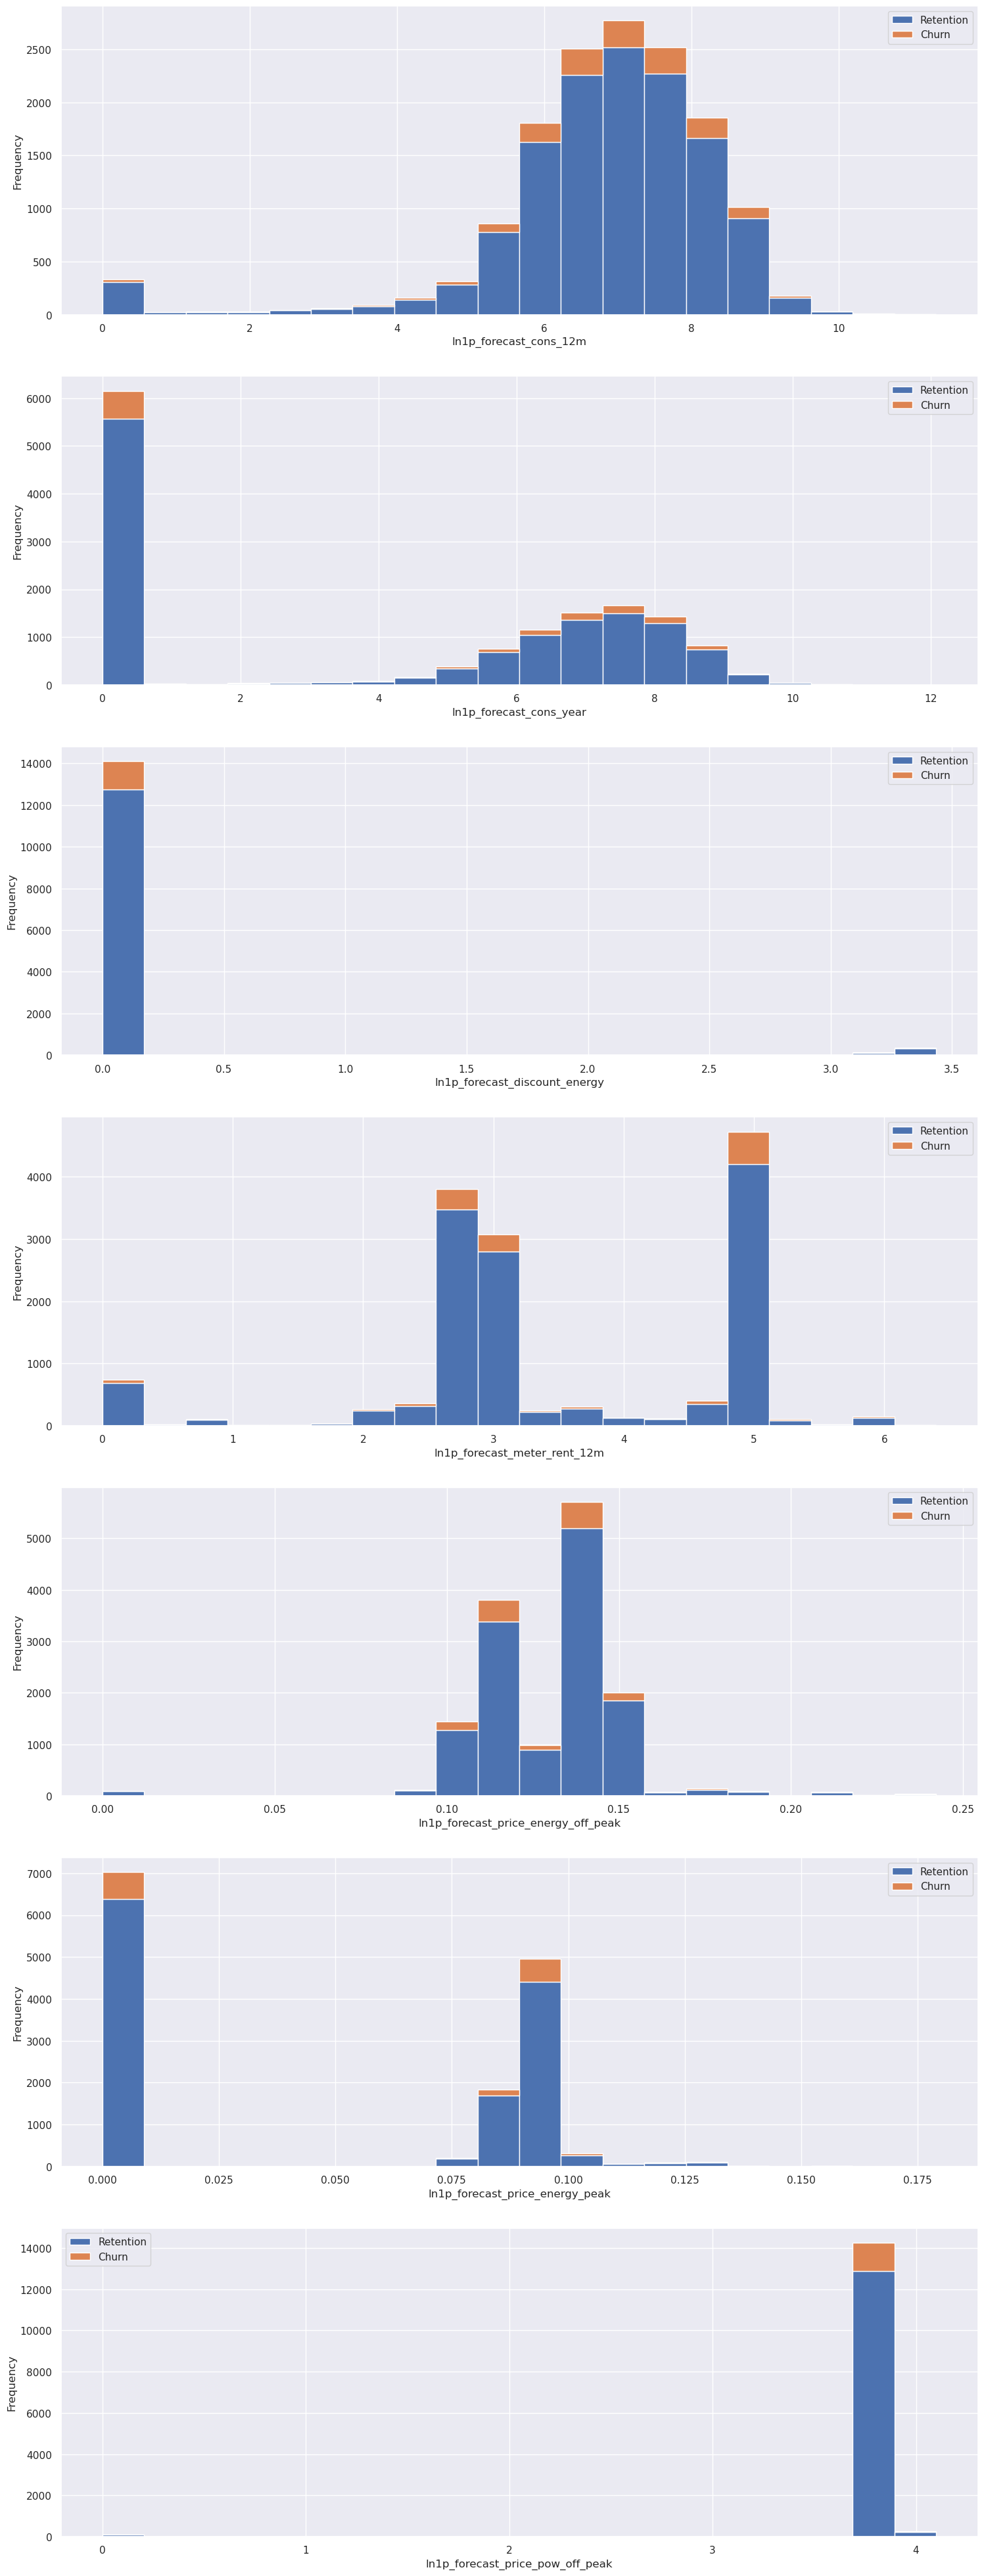

In [ ]:
fig, axs = plt.subplots(nrows=len(list_transf_forecast), figsize=(18,50))

for i, dfcol in enumerate(list_transf_forecast):
    plot_distribution(transf_forecast, dfcol, axs[i], bins_=20)

We can keep the forecasts for the consumption in the next 12 months and calendar year

In [ ]:
# New transformed columns and has_gas column if they are not in df_out
missing_cols = set(list_transf_forecast[:2]) - set(df_out.columns)
# Convert to list so I can use it in the dataframe
missing_cols = list(missing_cols)
# Add the missing columns to the output dataframe
df_out[missing_cols] = transf_forecast[missing_cols]

print(df_out.columns)

Index(['id', 'churn', 'ch_sales_id', 'cons12m_is_zero', 'cons_gas_12m_is_zero',
       'cons_last_month_is_zero', 'imp_cons_is_zero', 'ln1p_cons_last_month',
       'ln1p_cons_12m', 'ln1p_imp_cons', 'has_gas', 'ln1p_cons_gas_12m',
       'ln1p_forecast_cons_year', 'ln1p_forecast_cons_12m'],
      dtype='object')


And columns indicating where the forecast for consumption are 0

In [ ]:
df_out["forecast_cons_12m_is_zero"] = (df["forecast_cons_12m"] == 0.0).astype(int)
df_out["forecast_cons_year_is_zero"] = (df["forecast_cons_year"] == 0.0).astype(int)


## Number of products

In [ ]:
df_out["nb_prod_act"] = df["nb_prod_act"]

## Number of antiquity years as a client 

In [ ]:
df_out["num_years_antig"] = df["num_years_antig"]

## Extra features from the prices datasets

Original price variation in a year and 6 months 

In [ ]:
cols_var_year = df.filter(like="var_year").columns
df_out[cols_var_year] = df[cols_var_year]

cols_var_6m = df.filter(like="var_6m").columns
df_out[cols_var_6m] = df[cols_var_6m]

The prices along the year for companies that has churn is larger than for those that did not churned.  
Some of the variable and fixed prices shows a more contant price along the year and a clearer separation of the prices for churn and retained companies. We can obtain the average price along the year for: {"price_mid_peak_var", "price_mid_peak_fix", "price_peak_fix"}.


In [ ]:
# Filter prices by the clients that are in the clean df
# And calculate averages per id and month
monthly_price_by_id = price_df[ 
    price_df["id"].isin(df["id"]) 
    ].groupby(
        ['id', 'price_date']
              ).agg(
                  {'price_mid_peak_var': 'mean', 
                   'price_mid_peak_fix': 'mean', 
                   'price_peak_fix': 'mean'}
                   ).reset_index()

# Average price per year
# Group by id
# Calculate mean in the selected price fields
# And rename the columns as avg_***
# Finally, get back "id" as a column, because it was by default, set as the index of the dataframe.
avg_year_price_by_id = (
    monthly_price_by_id.groupby("id")[["price_mid_peak_var", "price_mid_peak_fix", "price_peak_fix"]]
      .mean()
      .add_prefix("avg_")
).reset_index()

display(avg_year_price_by_id)


,id,avg_price_mid_peak_var,avg_price_mid_peak_fix,avg_price_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.073160,16.280694,24.421038
1,0004351ebdd665e6ee664792efc4fd13,0.000000,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.000000,0.000000,0.000000
3,00114d74e963e47177db89bc70108537,0.000000,0.000000,0.000000
4,0013f326a839a2f6ad87a1859952d227,0.074921,16.291555,24.437330
...,...,...,...,...
14601,ffebf6a979dd0b17a41076df1057e733,0.072210,16.242678,24.364017
14602,fffac626da707b1b5ab11e8431a4d0a2,0.000000,0.000000,0.000000
14603,fffc0cacd305dd51f316424bbb08d1bd,0.094842,16.763569,24.895768
14604,fffe4f5646aa39c7f97f95ae2679ce64,0.073735,16.242678,24.364017


Add the yearly avg prices to the df

In [ ]:
df_out = pd.merge(left=df_out, right=avg_year_price_by_id, on="id")
df_out.columns

Index(['id', 'churn', 'ch_sales_id', 'cons12m_is_zero', 'cons_gas_12m_is_zero',
       'cons_last_month_is_zero', 'imp_cons_is_zero', 'ln1p_cons_last_month',
       'ln1p_cons_12m', 'ln1p_imp_cons', 'has_gas', 'ln1p_cons_gas_12m',
       'ln1p_forecast_cons_year', 'ln1p_forecast_cons_12m',
       'forecast_cons_12m_is_zero', 'forecast_cons_year_is_zero',
       'nb_prod_act', 'num_years_antig', 'var_year_price_off_peak_var',
       'var_year_price_peak_var', 'var_year_price_mid_peak_var',
       'var_year_price_off_peak_fix', 'var_year_price_peak_fix',
       'var_year_price_mid_peak_fix', 'var_year_price_off_peak',
       'var_year_price_peak', 'var_year_price_mid_peak',
       'var_6m_price_off_peak_var', 'var_6m_price_peak_var',
       'var_6m_price_mid_peak_var', 'var_6m_price_off_peak_fix',
       'var_6m_price_peak_fix', 'var_6m_price_mid_peak_fix',
       'var_6m_price_off_peak', 'var_6m_price_peak', 'var_6m_price_mid_peak',
       'avg_price_mid_peak_var', 'avg_price_mid_peak_f

In [ ]:
df_out[["var_6m_price_mid_peak", "churn"]]

,var_6m_price_mid_peak,churn
0,4.423670e+01,1
1,0.000000e+00,0
2,0.000000e+00,0
3,0.000000e+00,0
4,4.860000e-10,0
...,...,...
14601,0.000000e+00,0
14602,2.987132e-04,1
14603,4.860000e-10,1
14604,0.000000e+00,0


### Plot


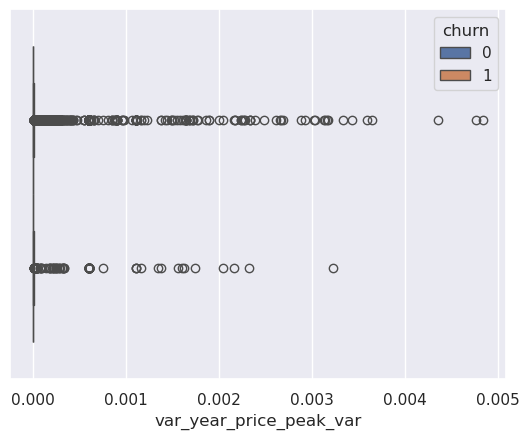

In [ ]:
# avg prices from churning companies vs Retained companies
# col_= "avg_price_mid_peak_fix"
# col_= "var_year_price_peak"
col_= "var_year_price_peak_var"


condition_ = (df_out[col_]>0.0)
sns.boxplot(df_out[condition_], x=col_, hue="churn")
ax = plt.gca()
# ax.set_xlim(0. , 1e-1)
plt.show()